# Time pressure analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy import stats
import chess
import chess.engine

In [2]:
# Increase font size a bit
plt.rcParams.update({'font.size': 16})

## Load the data

In [3]:
# Load the data
high_moves = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/high_voc_moves.csv')
high_games = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/high_voc_games.csv')
low_moves = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/low_voc_moves.csv')
low_games = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/low_voc_games.csv')

In [4]:
# Display a moves table
high_moves

,gid,move_ply,move_uci,move_time,player_white,player_clock_time,opponent_clock_time,board_position,castling_rights,en_passant_targets,halfmove_clock,n_possible_moves,n_pieces,player_in_check,partition
0,202201093030742,30,g7g5,0.0,False,30.0,29.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202201
1,202201093142124,30,g7g5,23.0,False,193.0,190.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202201
2,202201093488857,30,g7g5,5.0,False,284.0,265.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202201
3,202201093520261,30,d5f6,72.0,False,583.0,562.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202201
4,202201093604763,30,g7g5,2.0,False,591.0,576.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15140,202312046806035,30,h7h6,71.0,False,184.0,199.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202312
15141,202312025497345,30,g7g5,0.0,False,68.0,10.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202312
15142,202312025532641,30,c8d7,46.0,False,272.0,284.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202312
15143,202312025687892,30,g7g5,16.0,False,116.0,118.0,r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RN...,NaN,NaN,2,47,27,False,202312


In [5]:
# Display a games table
high_games

,gid,id,utc_datetime,initial_clock,clock_increment,opening,white_id,black_id,white_title,black_title,white_elo,black_elo,white_elo_change,black_elo_change,white_won,black_won,game_end_type,n_moves,partition
0,202201093030742,r0dPBwQv,2022-01-28 20:51:48,30.0,0.0,"Ruy Lopez: Marshall Attack, Modern Main Line",BlazikenBot2000,Karpov_bot,BOT,BOT,2662,2742,-5.0,4.0,False,True,Normal,198,202201
1,202201093142124,S2g6hjpx,2022-01-28 21:34:46,180.0,2.0,"Ruy Lopez: Marshall Attack, Modern Main Line",Abdulhakimal03,itachi60011,NaN,NaN,2011,2060,-4.0,5.0,False,True,Normal,59,202201
2,202201093488857,O2fM4hBi,2022-01-29 00:21:58,300.0,0.0,"Ruy Lopez: Marshall Attack, Modern Main Line",Ivanhoe2010,trivial_pursuit,NaN,NaN,2004,1888,3.0,-4.0,True,False,Time forfeit,89,202201
3,202201093520261,sPcZ3sV2,2022-01-29 00:41:55,600.0,0.0,"Ruy Lopez: Marshall Attack, Modern Main Line",jarwosatu,harryraphael89,NaN,NaN,2165,2122,5.0,-5.0,True,False,Normal,109,202201
4,202201093604763,q1jRa6Af,2022-01-29 01:42:14,600.0,0.0,"Ruy Lopez: Marshall Attack, Modern Main Line",AboutToBlunder,OrangeCadillac,NaN,NaN,1913,2152,4.0,-3.0,False,False,Normal,130,202201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15136,202312046806035,y1yncCyd,2023-12-15 18:32:06,180.0,2.0,"Ruy Lopez: Marshall Attack, Modern Main Line",Andreas001,Grosbol,NaN,NaN,2138,2275,-4.0,3.0,False,True,Normal,48,202312
15137,202312025497345,jh4l9kPK,2023-12-08 21:26:56,60.0,1.0,"Ruy Lopez: Marshall Attack, Modern Main Line",Lili-ai,torbot_v2,BOT,NaN,2812,2967,NaN,NaN,False,False,Normal,120,202312
15138,202312025532641,UU6LFQ1V,2023-12-08 21:42:09,300.0,0.0,"Ruy Lopez: Marshall Attack, Modern Main Line",shiitaco,robtorresc,NaN,NaN,2050,2044,-5.0,12.0,False,True,Normal,58,202312
15139,202312025687892,NEVhSCv4,2023-12-08 22:54:49,120.0,1.0,"Ruy Lopez: Marshall Attack, Modern Main Line",ALEPOV,Mikono,NaN,NaN,1713,1745,6.0,-7.0,True,False,Time forfeit,69,202312


## Summary statistics

In [6]:
# Merge the dataframes
high_all = pd.merge(high_games, high_moves, on='gid')
low_all = pd.merge(low_games, low_moves, on='gid')

In [7]:
# Filter out bots
high_all = high_all.drop((high_all[high_all['white_title'] == 'BOT'].index) | (high_all[high_all['black_title'] == 'BOT'].index))
low_all = low_all.drop((low_all[low_all['white_title'] == 'BOT'].index) | (low_all[low_all['black_title'] == 'BOT'].index))

In [8]:
len(high_all), len(low_all)

(12786, 12384)

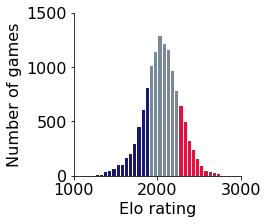

In [9]:
# Plot the distribution of elos (high voc)
high_elos = high_all['black_elo'].values
bins = list(range(1000,3000,50))

fig, ax = plt.subplots(figsize=(3,3))
n, bins, patches = plt.hist(high_elos, bins,  edgecolor='white', color='lightslategray')
# Color the bars based on the x-value
for i, patch in enumerate(patches):
    if bins[i] < 1877:
        patch.set_facecolor('midnightblue')
    elif bins[i] > 2226:
        patch.set_facecolor('crimson')
ax.set_xlabel('Elo rating')
ax.set_ylabel('Number of games')
ax.set_xlim(1000,3000)
ax.set_yticks([0,500,1000,1500])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('elo_dist_high.png', format='png', dpi=1000,bbox_inches = 'tight')

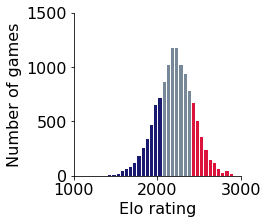

In [10]:
# Plot the distribution of elos (low voc)
low_elos = low_all['black_elo'].values
bins = list(range(1000,3500,50))

fig, ax = plt.subplots(figsize=(3,3))
n, bins, patches = plt.hist(low_elos, bins,  edgecolor='white', color='lightslategray')
# Color the bars based on the x-value
for i, patch in enumerate(patches):
    if bins[i] < 2011:
        patch.set_facecolor('midnightblue')
    elif bins[i] > 2386:
        patch.set_facecolor('crimson')
ax.set_xlabel('Elo rating')
ax.set_ylabel('Number of games')
ax.set_xlim(1000,3000)
ax.set_yticks([0,500,1000,1500])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('elo_dist_low.png', format='png', dpi=1000,bbox_inches = 'tight')

In [9]:
# Get the values for the time control setting (high voc)
high_time_controls = []
high_elos_time_control = []
high_elochange_time_control = []
high_rts_time_control = []
high_moves_time_control = []
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3', '600+0', '600+5', '900+10', '1800+0', '1800+20']

for ind in high_all.index:
    initial_clock = high_all['initial_clock'][ind]
    increment = high_all['clock_increment'][ind]
    if np.isnan(initial_clock) == False and np.isnan(increment) == False:
        time_control = str(int(initial_clock))+'+'+str(int(increment))
        if time_control in valid_controls:
            high_time_controls.append(time_control)
            high_elos_time_control.append(high_all['black_elo'][ind])
            high_elochange_time_control.append(high_all['black_elo_change'][ind])
            high_rts_time_control.append(high_all['move_time'][ind])
            high_moves_time_control.append(high_all['move_uci'][ind])

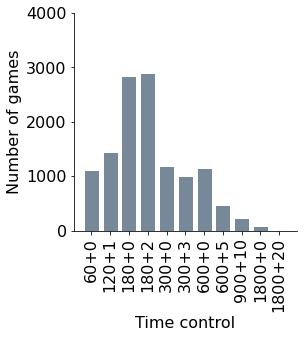

In [14]:
# Plot the distribution of time controls (high voc)
freqs = Counter(high_time_controls)
xvals = range(len(freqs.values()))
sorted_freqs = dict(sorted(freqs.items(), key=lambda item: valid_controls.index(item[0])))

fig, ax = plt.subplots(figsize=(4,4))
ax.bar(xvals, sorted_freqs.values(), edgecolor='white', color='lightslategray')
ax.set_xlabel('Time control')
ax.set_ylabel('Number of games')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(xvals)
ax.set_xticklabels(list(sorted_freqs.keys()))
ax.set_yticks([0,1000,2000,3000,4000])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [13]:
print(sorted_freqs)

{'60+0': 1108, '120+1': 1454, '180+0': 2837, '180+2': 2907, '300+0': 1196, '300+3': 1010, '600+0': 1146, '600+5': 473, '900+10': 240, '1800+0': 75, '1800+20': 12}


In [10]:
# Get the values for the time control setting (low voc)
low_time_controls = []
low_elos_time_control = []
low_elochange_time_control = []
low_rts_time_control = []
low_moves_time_control = []
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3', '600+0', '600+5', '900+10', '1800+0', '1800+20']

for ind in low_all.index:
    initial_clock = low_all['initial_clock'][ind]
    increment = low_all['clock_increment'][ind]
    if np.isnan(initial_clock) == False and np.isnan(increment) == False:
        time_control = str(int(initial_clock))+'+'+str(int(increment))
        if time_control in valid_controls:
            low_time_controls.append(time_control)
            low_elos_time_control.append(low_all['black_elo'][ind])
            low_elochange_time_control.append(low_all['black_elo_change'][ind])
            low_rts_time_control.append(low_all['move_time'][ind])
            low_moves_time_control.append(low_all['move_uci'][ind])

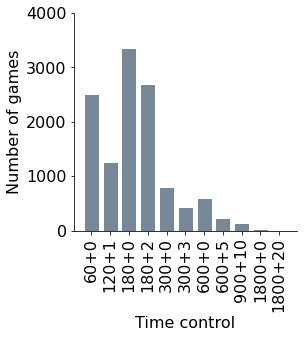

In [11]:
# Plot the distribution of time controls (low voc)
freqs = Counter(low_time_controls)
xvals = range(len(freqs.values()))
sorted_freqs = dict(sorted(freqs.items(), key=lambda item: valid_controls.index(item[0])))

fig, ax = plt.subplots(figsize=(4,4))
ax.bar(xvals, sorted_freqs.values(), edgecolor='white', color='lightslategray')
ax.set_xlabel('Time control')
ax.set_ylabel('Number of games')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(xvals)
ax.set_xticklabels(list(sorted_freqs.keys()))
ax.set_yticks([0,1000,2000,3000,4000])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [16]:
print(sorted_freqs)

{'60+0': 2514, '120+1': 1253, '180+0': 3364, '180+2': 2702, '300+0': 796, '300+3': 435, '600+0': 599, '600+5': 238, '900+10': 143, '1800+0': 28, '1800+20': 8}


## Time control

In [12]:
# Compute response times as a function of time controls
avg_rts_low = []
sem_rts_low = []
avg_rts_high = []
sem_rts_high = []
rts_low = np.asarray(low_rts_time_control)
rts_high = np.asarray(high_rts_time_control)
for i in range(len(valid_controls)):
    avg_rts_low.append(np.nanmean(rts_low[np.where(np.asarray(low_time_controls)==valid_controls[i])]).item())
    sem_rts_low.append(stats.sem(rts_low[np.where(np.asarray(low_time_controls)==valid_controls[i])]).item())
    avg_rts_high.append(np.nanmean(rts_high[np.where(np.asarray(high_time_controls)==valid_controls[i])]).item())
    sem_rts_high.append(stats.sem(rts_high[np.where(np.asarray(high_time_controls)==valid_controls[i])]).item())

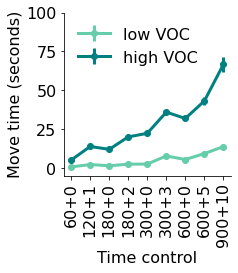

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], avg_rts_low[0:9], yerr = sem_rts_low[0:9], marker='o', color='mediumaquamarine', lw=3, label = 'low VOC')
ax.errorbar(xvals[0:9], avg_rts_high[0:9], yerr = sem_rts_high[0:9], marker='o', color='teal', lw=3, label = 'high VOC')
ax.set_xlabel('Time control')
ax.set_ylabel('Move time (seconds)')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-5,100)
ax.legend(loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_time.png', format='png', dpi=1000,bbox_inches = 'tight')

In [14]:
# Compute variance of responses as a function of time control
high_var = []
low_var = []
for i in range(len(valid_controls)):
    unique, counts = np.unique(np.asarray(high_moves_time_control)[np.where(np.asarray(high_time_controls)==valid_controls[i])], return_counts=True)
    high_var.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(low_moves_time_control)[np.where(np.asarray(low_time_controls)==valid_controls[i])], return_counts=True)
    low_var.append(stats.entropy(counts))

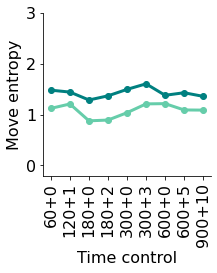

In [15]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], low_var[0:9], marker='o', color='mediumaquamarine', lw=3)
ax.errorbar(xvals[0:9], high_var[0:9], marker='o', color='teal', lw=3)
ax.set_xlabel('Time control')
ax.set_ylabel('Move entropy')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-0.2,3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_variance.png', format='png', dpi=1000,bbox_inches = 'tight')

In [16]:
# Set up the engine
stockfish_path = '/opt/homebrew/opt/stockfish/bin/stockfish'
engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)

In [17]:
# Analyze each of the unique moves
quality_high_ref = {}
board_fen = 'r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RNBQ2K1 b'
unique_high_moves = np.unique(high_moves_time_control)
for move in unique_high_moves:
    new_board = chess.Board(board_fen)
    new_board.push_uci(move)
    engine.configure({"Clear Hash": None})
    info = engine.analyse(new_board, chess.engine.Limit(depth=15))
    quality_high_ref[move] = -info["score"].relative.score()
    
quality_low_ref = {}
board_fen = 'r2qk2r/pp2bpp1/2p1pn1p/7P/3P4/5N2/PPPBQPP1/2KR3R b KQkq'
unique_low_moves = np.unique(low_moves_time_control)
for move in unique_low_moves:
    new_board = chess.Board(board_fen)
    new_board.push_uci(move)
    engine.configure({"Clear Hash": None})
    info = engine.analyse(new_board, chess.engine.Limit(depth=15))
    quality_low_ref[move] = -info["score"].relative.score()

In [18]:
# Add the moves to a list
quality_high = []
for move in high_moves_time_control:
    quality_high.append(quality_high_ref[move])
    
quality_low = []
for move in low_moves_time_control:
    quality_low.append(quality_low_ref[move])

In [19]:
# Compute move quality as a function of time controls
avg_quality_high = []
sem_quality_high = []
avg_quality_low = []
sem_quality_low = []
for i in range(len(valid_controls)):
    avg_quality_high.append(np.nanmean(np.asarray(quality_high)[np.where(np.asarray(high_time_controls)==valid_controls[i])]).item())
    sem_quality_high.append(stats.sem(np.asarray(quality_high)[np.where(np.asarray(high_time_controls)==valid_controls[i])]).item())
    avg_quality_low.append(np.nanmean(np.asarray(quality_low)[np.where(np.asarray(low_time_controls)==valid_controls[i])]).item())
    sem_quality_low.append(stats.sem(np.asarray(quality_low)[np.where(np.asarray(low_time_controls)==valid_controls[i])]).item())

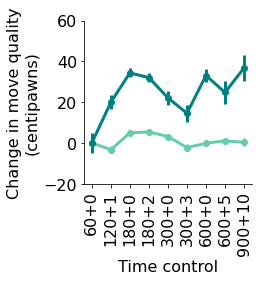

In [90]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], np.asarray(avg_quality_low[0:9])-avg_quality_low[0], yerr = sem_quality_low[0:9], marker='o', color='mediumaquamarine', lw=3)
ax.errorbar(xvals[0:9], np.asarray(avg_quality_high[0:9])-avg_quality_high[0], yerr = sem_quality_high[0:9], marker='o', color='teal', lw=3)
ax.set_xlabel('Time control')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.set_ylim(-20,60)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_quality.png', format='png', dpi=1000,bbox_inches = 'tight')

## Clock time

In [91]:
# Filter the clock times (high voc)
high_clock_filt = []
high_rts_filt = []
high_moves_filt = []
high_elos_filt = []
high_elochange_filt = []

for ind in high_all.index:
    if np.isnan(high_all['player_clock_time'][ind]) == False and np.isnan(high_all['move_time'][ind]) == False and np.isnan(high_all['black_elo_change'][ind]) == False:
        high_elos_filt.append(high_all['black_elo'][ind])
        high_elochange_filt.append(high_all['black_elo_change'][ind])
        high_rts_filt.append(high_all['move_time'][ind])
        high_clock_filt.append(high_all['player_clock_time'][ind])
        high_moves_filt.append(high_all['move_uci'][ind])

In [92]:
# Filter the clock times (low voc)
low_clock_filt = []
low_rts_filt = []
low_moves_filt = []
low_elos_filt = []
low_elochange_filt = []

for ind in low_all.index:
    if np.isnan(low_all['player_clock_time'][ind]) == False and np.isnan(low_all['move_time'][ind]) == False and np.isnan(low_all['black_elo_change'][ind]) == False:
        low_elos_filt.append(low_all['black_elo'][ind])
        low_elochange_filt.append(low_all['black_elo_change'][ind])
        low_rts_filt.append(low_all['move_time'][ind])
        low_clock_filt.append(low_all['player_clock_time'][ind])
        low_moves_filt.append(low_all['move_uci'][ind])

In [93]:
# Compute response times as a function of clock time
bin_means_low, bin_edges, binnumber = stats.binned_statistic(low_clock_filt, low_rts_filt, statistic='mean', bins=6, range=(0,900))
bin_sem_low, bin_edges_sem, binnumber_sem = stats.binned_statistic(low_clock_filt, low_rts_filt, statistic=stats.sem, bins=6, range=(0,900))

bin_means_high, bin_edges, binnumber = stats.binned_statistic(high_clock_filt, high_rts_filt, statistic='mean', bins=6, range=(0,900))
bin_sem_high, bin_edges_sem, binnumber_sem = stats.binned_statistic(high_clock_filt, high_rts_filt, statistic=stats.sem, bins=6, range=(0,900))

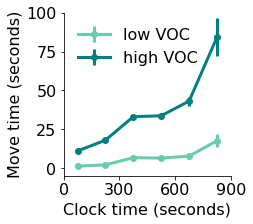

In [94]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(bin_edges[:-1]+75, bin_means_low, yerr = bin_sem_low, marker='o', color='mediumaquamarine', lw=3, label = 'low VOC')
ax.errorbar(bin_edges[:-1]+75, bin_means_high, yerr = bin_sem_high, marker='o', color='teal', lw=3, label = 'high VOC')
ax.set_xticks([0,300,600,900])
ax.set_xlabel('Clock time (seconds)')
ax.set_ylabel('Move time (seconds)')
ax.set_ylim(-5,100)
ax.legend(loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_time_clock.png', format='png', dpi=1000,bbox_inches = 'tight')

In [95]:
# Compute variance of responses as a function of clock time
high_var_clock = []
low_var_clock = []
for i in range(len(bin_edges)-1):
    unique, counts = np.unique(np.asarray(high_moves_filt)[np.where((high_clock_filt>=bin_edges[i]) & (high_clock_filt<bin_edges[i+1]))], return_counts=True)
    high_var_clock.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(low_moves_filt)[np.where((low_clock_filt>=bin_edges[i]) & (low_clock_filt<bin_edges[i+1]))], return_counts=True)
    low_var_clock.append(stats.entropy(counts))

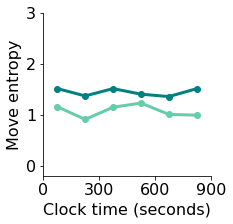

In [96]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(bin_edges[:-1]+75, low_var_clock, marker='o', color='mediumaquamarine', lw=3)
ax.errorbar(bin_edges[:-1]+75, high_var_clock, marker='o', color='teal', lw=3)
ax.set_xticks([0,300,600,900])
ax.set_ylim(-0.2,3)
ax.set_xlabel('Clock time (seconds)')
ax.set_ylabel('Move entropy')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_variance_clock.png', format='png', dpi=1000,bbox_inches = 'tight')

In [97]:
# Analyze each of the unique moves
quality_high_ref = {}
board_fen = 'r1b2rk1/5ppp/p1pb4/1p1n4/3PR3/1BP3Pq/PP3P1P/RNBQ2K1 b'
unique_high_moves = np.unique(high_moves_filt)
for move in unique_high_moves:
    new_board = chess.Board(board_fen)
    new_board.push_uci(move)
    engine.configure({"Clear Hash": None})
    info = engine.analyse(new_board, chess.engine.Limit(depth=15))
    quality_high_ref[move] = -info["score"].relative.score()
    
quality_low_ref = {}
board_fen = 'r2qk2r/pp2bpp1/2p1pn1p/7P/3P4/5N2/PPPBQPP1/2KR3R b KQkq'
unique_low_moves = np.unique(low_moves_filt)
for move in unique_low_moves:
    new_board = chess.Board(board_fen)
    new_board.push_uci(move)
    engine.configure({"Clear Hash": None})
    info = engine.analyse(new_board, chess.engine.Limit(depth=15))
    quality_low_ref[move] = -info["score"].relative.score()

In [98]:
# Add the unique moves to a list
quality_high_filt = []
for move in high_moves_filt:
    quality_high_filt.append(quality_high_ref[move])
    
quality_low_filt = []
for move in low_moves_filt:
    quality_low_filt.append(quality_low_ref[move])

In [99]:
# Compute move quality as a function of clock time
bin_means_low, bin_edges, binnumber = stats.binned_statistic(low_clock_filt, quality_low_filt, statistic='mean', bins=6, range=(0,900))
bin_sem_low, bin_edges_sem, binnumber_sem = stats.binned_statistic(low_clock_filt, quality_low_filt, statistic=stats.sem, bins=6, range=(0,900))

bin_means_high, bin_edges, binnumber = stats.binned_statistic(high_clock_filt, quality_high_filt, statistic='mean', bins=6, range=(0,900))
bin_sem_high, bin_edges_sem, binnumber_sem = stats.binned_statistic(high_clock_filt, quality_high_filt, statistic=stats.sem, bins=6, range=(0,900))

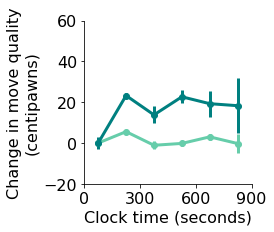

In [103]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(bin_edges[:-1]+75, bin_means_low-bin_means_low[0], yerr = bin_sem_low, marker='o', color='mediumaquamarine', lw=3)
ax.errorbar(bin_edges[:-1]+75, bin_means_high-bin_means_high[0], yerr = bin_sem_high, marker='o', color='teal', lw=3)
ax.set_xticks([0,300,600,900])
ax.set_xlabel('Clock time (seconds)')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.set_ylim(-20,60)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_quality_clock.png', format='png', dpi=1000,bbox_inches = 'tight')

## Playing strength

In [104]:
# Compute the elo quantiles
np.quantile(low_elos_time_control, [0.2, 0.8]), np.quantile(high_elos_time_control, [0.2, 0.8])

(array([2011., 2386.]), array([1877., 2226.]))

In [105]:
# Compute response times as a function of time controls split by elo quantiles
avg_rts_high_elo1 = []
sem_rts_high_elo1 = []
avg_rts_high_elo2 = []
sem_rts_high_elo2 = []
avg_rts_high_elo3 = []
sem_rts_high_elo3 = []

rts_high = np.asarray(high_rts_time_control)
for i in range(len(valid_controls)):
    avg_rts_high_elo1.append(np.nanmean(rts_high[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) < 1877))]).item())
    sem_rts_high_elo1.append(stats.sem(rts_high[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) < 1877))]).item())
    avg_rts_high_elo2.append(np.nanmean(rts_high[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 1877) & (np.asarray(high_elos_time_control) < 2226))]).item())
    sem_rts_high_elo2.append(stats.sem(rts_high[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 1877) & (np.asarray(high_elos_time_control) < 2226))]).item())
    avg_rts_high_elo3.append(np.nanmean(rts_high[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 2226))]).item())
    sem_rts_high_elo3.append(stats.sem(rts_high[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 2226))]).item())

/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: Mean of empty slice
  from ipykernel import kernelapp as app
/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)


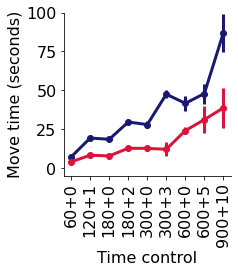

In [106]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], avg_rts_high_elo1[0:9], yerr = sem_rts_high_elo1[0:9], marker='o', color='midnightblue', lw=3, label = '< 1917')
# ax.errorbar(xvals[0:9], avg_rts_high_elo2[0:9], yerr = sem_rts_high_elo2[0:9], marker='o', color='darkorchid', lw=3, label = '1917 - 2148')
ax.errorbar(xvals[0:9], avg_rts_high_elo3[0:9], yerr = sem_rts_high_elo3[0:9], marker='o', color='crimson', lw=3, label = '> 2148')
ax.set_xlabel('Time control')
ax.set_ylabel('Move time (seconds)')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-5,100)
# ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_time_elo_high.png', format='png', dpi=1000,bbox_inches = 'tight')

In [107]:
# Compute response times as a function of time controls split by elo quantiles
avg_rts_low_elo1 = []
sem_rts_low_elo1 = []
avg_rts_low_elo2 = []
sem_rts_low_elo2 = []
avg_rts_low_elo3 = []
sem_rts_low_elo3 = []

rts_low = np.asarray(low_rts_time_control)
for i in range(len(valid_controls)):
    avg_rts_low_elo1.append(np.nanmean(rts_low[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) < 2011))]).item())
    sem_rts_low_elo1.append(stats.sem(rts_low[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) < 2011))]).item())
    avg_rts_low_elo2.append(np.nanmean(rts_low[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2011) & (np.asarray(low_elos_time_control) < 2386))]).item())
    sem_rts_low_elo2.append(stats.sem(rts_low[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2011) & (np.asarray(low_elos_time_control) < 2386))]).item())
    avg_rts_low_elo3.append(np.nanmean(rts_low[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2386))]).item())
    sem_rts_low_elo3.append(stats.sem(rts_low[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2386))]).item())

/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: Mean of empty slice
  from ipykernel import kernelapp as app


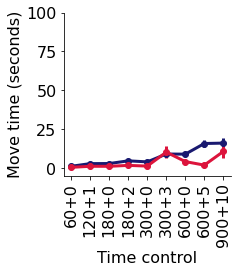

In [108]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], avg_rts_low_elo1[0:9], yerr = sem_rts_low_elo1[0:9], marker='o', color='midnightblue', lw=3, label = '< 2109')
# ax.errorbar(xvals[0:9], avg_rts_low_elo2[0:9], yerr = sem_rts_low_elo2[0:9], marker='o', color='darkorchid', lw=3, label = '2109 - 2292')
ax.errorbar(xvals[0:9], avg_rts_low_elo3[0:9], yerr = sem_rts_low_elo3[0:9], marker='o', color='crimson', lw=3, label = '> 2292')
ax.set_xlabel('Time control')
ax.set_ylabel('Move time (seconds)')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-5,100)
# ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_time_elo_low.png', format='png', dpi=1000,bbox_inches = 'tight')

In [109]:
# Compute move quality as a function of time controls split by elo quantiles
avg_quality_high_elo1 = []
sem_quality_high_elo1 = []
avg_quality_high_elo2 = []
sem_quality_high_elo2 = []
avg_quality_high_elo3 = []
sem_quality_high_elo3 = []

for i in range(len(valid_controls)):
    avg_quality_high_elo1.append(np.nanmean(np.asarray(quality_high)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) < 1877))]).item())
    sem_quality_high_elo1.append(stats.sem(np.asarray(quality_high)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) < 1877))]).item())
    avg_quality_high_elo2.append(np.nanmean(np.asarray(quality_high)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 1877) & (np.asarray(high_elos_time_control) < 2226))]).item())
    sem_quality_high_elo2.append(stats.sem(np.asarray(quality_high)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 1877) & (np.asarray(high_elos_time_control) < 2226))]).item())
    avg_quality_high_elo3.append(np.nanmean(np.asarray(quality_high)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 2226))]).item())
    sem_quality_high_elo3.append(stats.sem(np.asarray(quality_high)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 2226))]).item())

/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


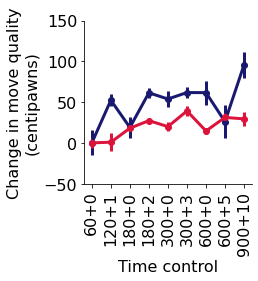

In [125]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], np.asarray(avg_quality_high_elo1[0:9])-avg_quality_high_elo1[0], yerr = sem_quality_high_elo1[0:9], marker='o', color='midnightblue', lw=3, label = '< 1917')
ax.errorbar(xvals[0:9], np.asarray(avg_quality_high_elo3[0:9])-avg_quality_high_elo3[0], yerr = sem_quality_high_elo3[0:9], marker='o', color='crimson', lw=3, label = '> 2148')
ax.set_xlabel('Time control')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-50,150)
# ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_quality_elo_high.png', format='png', dpi=1000,bbox_inches = 'tight')

In [118]:
# Compute move quality as a function of time controls split by elo quantiles
avg_quality_low_elo1 = []
sem_quality_low_elo1 = []
avg_quality_low_elo2 = []
sem_quality_low_elo2 = []
avg_quality_low_elo3 = []
sem_quality_low_elo3 = []

for i in range(len(valid_controls)):
    avg_quality_low_elo1.append(np.nanmean(np.asarray(quality_low)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) < 2011))]).item())
    sem_quality_low_elo1.append(stats.sem(np.asarray(quality_low)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) < 2011))]).item())
    avg_quality_low_elo2.append(np.nanmean(np.asarray(quality_low)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2011) & (np.asarray(low_elos_time_control) < 2386))]).item())
    sem_quality_low_elo2.append(stats.sem(np.asarray(quality_low)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2011) & (np.asarray(low_elos_time_control) < 2386))]).item())
    avg_quality_low_elo3.append(np.nanmean(np.asarray(quality_low)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2386))]).item())
    sem_quality_low_elo3.append(stats.sem(np.asarray(quality_low)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2386))]).item())

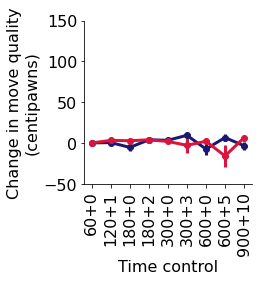

In [123]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], np.asarray(avg_quality_low_elo1[0:9])-avg_quality_low_elo1[0], yerr = sem_quality_low_elo1[0:9], marker='o', color='midnightblue', lw=3, label = '< 2109')
ax.errorbar(xvals[0:9], np.asarray(avg_quality_low_elo3[0:9])-avg_quality_low_elo3[0], yerr = sem_quality_low_elo3[0:9], marker='o', color='crimson', lw=3, label = '> 2292')
ax.set_xlabel('Time control')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-50,150)
# ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_quality_elo_low.png', format='png', dpi=1000,bbox_inches = 'tight')

In [424]:
# Compute variance of responses as a function of time control and split by elo quantiles
high_var_elo1 = []
high_var_elo2 = []
high_var_elo3 = []

for i in range(len(valid_controls)):
    unique, counts = np.unique(np.asarray(high_moves_time_control)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) < 1877))], return_counts=True)
    high_var_elo1.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(high_moves_time_control)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 1877) & (np.asarray(high_elos_time_control) < 2226))], return_counts=True)
    high_var_elo2.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(high_moves_time_control)[np.where((np.asarray(high_time_controls)==valid_controls[i]) & (np.asarray(high_elos_time_control) > 2226))], return_counts=True)
    high_var_elo3.append(stats.entropy(counts))


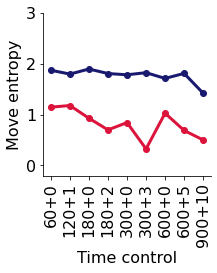

In [433]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], high_var_elo1[0:9], marker='o', color='midnightblue', lw=3, label = '< 1917')
# ax.errorbar(xvals[0:9], high_var_elo2[0:9], marker='o', color='darkorchid', lw=3, label = '1917 - 2148')
ax.errorbar(xvals[0:9], high_var_elo3[0:9], marker='o', color='crimson', lw=3, label = '> 2148')
ax.set_xlabel('Time control')
ax.set_ylabel('Move entropy')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-0.2,3)
# ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_variance_elo_high.png', format='png', dpi=1000,bbox_inches = 'tight')

In [429]:
# Compute variance of responses as a function of time control and split by elo quantiles
low_var_elo1 = []
low_var_elo2 = []
low_var_elo3 = []

for i in range(len(valid_controls)):
    unique, counts = np.unique(np.asarray(low_moves_time_control)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) < 2011))], return_counts=True)
    low_var_elo1.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(low_moves_time_control)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2011) & (np.asarray(low_elos_time_control) < 2386))], return_counts=True)
    low_var_elo2.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(low_moves_time_control)[np.where((np.asarray(low_time_controls)==valid_controls[i]) & (np.asarray(low_elos_time_control) > 2386))], return_counts=True)
    low_var_elo3.append(stats.entropy(counts))


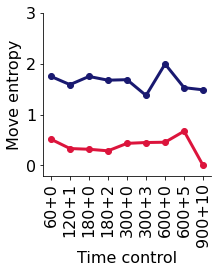

In [432]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], low_var_elo1[0:9], marker='o', color='midnightblue', lw=3, label = '< 1917')
# ax.errorbar(xvals[0:9], low_var_elo2[0:9], marker='o', color='darkorchid', lw=3, label = '1917 - 2148')
ax.errorbar(xvals[0:9], low_var_elo3[0:9], marker='o', color='crimson', lw=3, label = '> 2148')
ax.set_xlabel('Time control')
ax.set_ylabel('Move entropy')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-0.2,3)
# ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('move_variance_elo_low.png', format='png', dpi=1000,bbox_inches = 'tight')

## Replication to tile the VOC space

In [18]:
# Load the data
rep_moves1 = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/rep_voc_moves1.csv')
rep_games1 = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/rep_voc_games1.csv')
rep_moves2 = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/rep_voc_moves2.csv')
rep_games2 = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/rep_voc_games2.csv')
rep_moves3 = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/rep_voc_moves3.csv')
rep_games3 = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/rep_voc_games3.csv')

In [19]:
# Merge the dataframes
rep1_all = pd.merge(rep_games1, rep_moves1, on='gid')
rep2_all = pd.merge(rep_games2, rep_moves2, on='gid')
rep3_all = pd.merge(rep_games3, rep_moves3, on='gid')

In [20]:
# Filter out bots
rep1_all = rep1_all.drop((rep1_all[rep1_all['white_title'] == 'BOT'].index) | (rep1_all[rep1_all['black_title'] == 'BOT'].index))
rep2_all = rep2_all.drop((rep2_all[rep2_all['white_title'] == 'BOT'].index) | (rep2_all[rep2_all['black_title'] == 'BOT'].index))
rep3_all = rep3_all.drop((rep3_all[rep3_all['white_title'] == 'BOT'].index) | (rep3_all[rep3_all['black_title'] == 'BOT'].index))

In [21]:
len(rep1_all), len(rep2_all), len(rep3_all)

(8787, 7036, 8111)

In [86]:
# Get the values for the time control setting (rep1)
rep1_time_controls = []
rep1_elos_time_control = []
rep1_elochange_time_control = []
rep1_rts_time_control = []
rep1_moves_time_control = []
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3', '600+0', '600+5', '900+10', '1800+0', '1800+20']

for ind in rep1_all.index:
    initial_clock = rep1_all['initial_clock'][ind]
    increment = rep1_all['clock_increment'][ind]
    if np.isnan(initial_clock) == False and np.isnan(increment) == False:
        time_control = str(int(initial_clock))+'+'+str(int(increment))
        if time_control in valid_controls:
            rep1_time_controls.append(time_control)
            rep1_elos_time_control.append(rep1_all['white_elo'][ind])
            rep1_elochange_time_control.append(rep1_all['white_elo_change'][ind])
            rep1_rts_time_control.append(rep1_all['move_time'][ind])
            rep1_moves_time_control.append(rep1_all['move_uci'][ind])

In [87]:
# Get the values for the time control setting (rep2)
rep2_time_controls = []
rep2_elos_time_control = []
rep2_elochange_time_control = []
rep2_rts_time_control = []
rep2_moves_time_control = []
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3', '600+0', '600+5', '900+10', '1800+0', '1800+20']

for ind in rep2_all.index:
    initial_clock = rep2_all['initial_clock'][ind]
    increment = rep2_all['clock_increment'][ind]
    if np.isnan(initial_clock) == False and np.isnan(increment) == False:
        time_control = str(int(initial_clock))+'+'+str(int(increment))
        if time_control in valid_controls:
            rep2_time_controls.append(time_control)
            rep2_elos_time_control.append(rep2_all['white_elo'][ind])
            rep2_elochange_time_control.append(rep2_all['white_elo_change'][ind])
            rep2_rts_time_control.append(rep2_all['move_time'][ind])
            rep2_moves_time_control.append(rep2_all['move_uci'][ind])

In [88]:
# Get the values for the time control setting (rep3)
rep3_time_controls = []
rep3_elos_time_control = []
rep3_elochange_time_control = []
rep3_rts_time_control = []
rep3_moves_time_control = []
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3', '600+0', '600+5', '900+10', '1800+0', '1800+20']

for ind in rep3_all.index:
    initial_clock = rep3_all['initial_clock'][ind]
    increment = rep3_all['clock_increment'][ind]
    if np.isnan(initial_clock) == False and np.isnan(increment) == False:
        time_control = str(int(initial_clock))+'+'+str(int(increment))
        if time_control in valid_controls:
            rep3_time_controls.append(time_control)
            rep3_elos_time_control.append(rep3_all['white_elo'][ind])
            rep3_elochange_time_control.append(rep3_all['white_elo_change'][ind])
            rep3_rts_time_control.append(rep3_all['move_time'][ind])
            rep3_moves_time_control.append(rep3_all['move_uci'][ind])

In [28]:
# Compute response times as a function of time controls
avg_rts_rep1 = []
sem_rts_rep1 = []
avg_rts_rep2 = []
sem_rts_rep2 = []
avg_rts_rep3 = []
sem_rts_rep3 = []
rts_rep1 = np.asarray(rep1_rts_time_control)
rts_rep2 = np.asarray(rep2_rts_time_control)
rts_rep3 = np.asarray(rep3_rts_time_control)
for i in range(len(valid_controls)):
    avg_rts_rep1.append(np.nanmean(rts_rep1[np.where(np.asarray(rep1_time_controls)==valid_controls[i])]).item())
    sem_rts_rep1.append(stats.sem(rts_rep1[np.where(np.asarray(rep1_time_controls)==valid_controls[i])]).item())
    avg_rts_rep2.append(np.nanmean(rts_rep2[np.where(np.asarray(rep2_time_controls)==valid_controls[i])]).item())
    sem_rts_rep2.append(stats.sem(rts_rep2[np.where(np.asarray(rep2_time_controls)==valid_controls[i])]).item())
    avg_rts_rep3.append(np.nanmean(rts_rep3[np.where(np.asarray(rep3_time_controls)==valid_controls[i])]).item())
    sem_rts_rep3.append(stats.sem(rts_rep3[np.where(np.asarray(rep3_time_controls)==valid_controls[i])]).item())

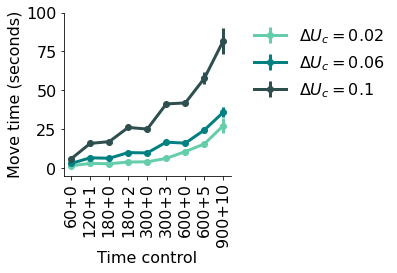

In [80]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], avg_rts_rep3[0:9], yerr = sem_rts_rep3[0:9], marker='o', color='mediumaquamarine', lw=3, label = '$\Delta U_c=0.02$')
ax.errorbar(xvals[0:9], avg_rts_rep1[0:9], yerr = sem_rts_rep1[0:9], marker='o', color='teal', lw=3, label = '$\Delta U_c=0.06$')
ax.errorbar(xvals[0:9], avg_rts_rep2[0:9], yerr = sem_rts_rep2[0:9], marker='o', color='darkslategray', lw=3, label = '$\Delta U_c=0.1$')
ax.set_xlabel('Time control')
ax.set_ylabel('Move time (seconds)')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-5,100)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('rep_move_time.png', format='png', dpi=1000,bbox_inches = 'tight')

In [43]:
# Compute variance of responses as a function of time control
rep1_var = []
rep2_var = []
rep3_var = []
for i in range(len(valid_controls)):
    unique, counts = np.unique(np.asarray(rep1_moves_time_control)[np.where(np.asarray(rep1_time_controls)==valid_controls[i])], return_counts=True)
    rep1_var.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(rep2_moves_time_control)[np.where(np.asarray(rep2_time_controls)==valid_controls[i])], return_counts=True)
    rep2_var.append(stats.entropy(counts))
    unique, counts = np.unique(np.asarray(rep3_moves_time_control)[np.where(np.asarray(rep3_time_controls)==valid_controls[i])], return_counts=True)
    rep3_var.append(stats.entropy(counts))

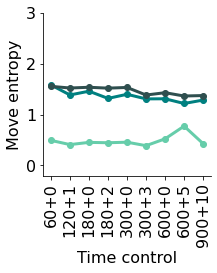

In [81]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], rep3_var[0:9], marker='o', color='mediumaquamarine', lw=3)
ax.errorbar(xvals[0:9], rep1_var[0:9], marker='o', color='teal', lw=3)
ax.errorbar(xvals[0:9], rep2_var[0:9], marker='o', color='darkslategray', lw=3)
ax.set_xlabel('Time control')
ax.set_ylabel('Move entropy')
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-0.2,3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('rep_move_variance.png', format='png', dpi=1000,bbox_inches = 'tight')

In [46]:
# Set up the engine
stockfish_path = '/opt/homebrew/opt/stockfish/bin/stockfish'
engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)

In [74]:
# Analyze each of the unique moves
quality_rep1_ref = {}
board_fen = 'r4rk1/5ppp/p2b4/1p1p3q/3P2b1/2P3P1/PP3PQP/RNB1R1K1 w'
unique_rep1_moves = np.unique(rep1_moves_time_control)
for move in unique_rep1_moves:
    new_board = chess.Board(board_fen)
    new_board.push_uci(move)
    engine.configure({"Clear Hash": None})
    info = engine.analyse(new_board, chess.engine.Limit(depth=15))
    quality_rep1_ref[move] = -info["score"].relative.score()

quality_rep2_ref = {}
board_fen = '4rrk1/5ppp/p1pb4/1p1n3q/3P2b1/1BP3P1/PP1N1PQP/R1B1R1K1 w'
unique_rep2_moves = np.unique(rep2_moves_time_control)
for move in unique_rep2_moves:
    new_board = chess.Board(board_fen)
    new_board.push_uci(move)
    engine.configure({"Clear Hash": None})
    info = engine.analyse(new_board, chess.engine.Limit(depth=15))
    quality_rep2_ref[move] = -info["score"].relative.score()
    
quality_rep3_ref = {}
board_fen = '4rrk1/5ppp/p1pb4/1p1n4/3P2b1/1BPQB1Pq/PP3P1P/RN2R1K1 w'
unique_rep3_moves = np.unique(rep3_moves_time_control)
for move in unique_rep3_moves:
    new_board = chess.Board(board_fen)
    new_board.push_uci(move)
    engine.configure({"Clear Hash": None})
    info = engine.analyse(new_board, chess.engine.Limit(depth=15))
    quality_rep3_ref[move] = -info["score"].relative.score(mate_score=1000)

In [75]:
# Add the moves to a list
quality_rep1 = []
for move in rep1_moves_time_control:
    quality_rep1.append(quality_rep1_ref[move])
    
quality_rep2 = []
for move in rep2_moves_time_control:
    quality_rep2.append(quality_rep2_ref[move])
    
quality_rep3 = []
for move in rep3_moves_time_control:
    quality_rep3.append(quality_rep3_ref[move])

In [76]:
# Compute move quality as a function of time controls
avg_quality_rep1 = []
sem_quality_rep1 = []
avg_quality_rep2 = []
sem_quality_rep2 = []
avg_quality_rep3 = []
sem_quality_rep3 = []
for i in range(len(valid_controls)):
    avg_quality_rep1.append(np.nanmean(np.asarray(quality_rep1)[np.where(np.asarray(rep1_time_controls)==valid_controls[i])]).item())
    sem_quality_rep1.append(stats.sem(np.asarray(quality_rep1)[np.where(np.asarray(rep1_time_controls)==valid_controls[i])]).item())
    avg_quality_rep2.append(np.nanmean(np.asarray(quality_rep2)[np.where(np.asarray(rep2_time_controls)==valid_controls[i])]).item())
    sem_quality_rep2.append(stats.sem(np.asarray(quality_rep2)[np.where(np.asarray(rep2_time_controls)==valid_controls[i])]).item())
    avg_quality_rep3.append(np.nanmean(np.asarray(quality_rep3)[np.where(np.asarray(rep3_time_controls)==valid_controls[i])]).item())
    sem_quality_rep3.append(stats.sem(np.asarray(quality_rep3)[np.where(np.asarray(rep3_time_controls)==valid_controls[i])]).item())

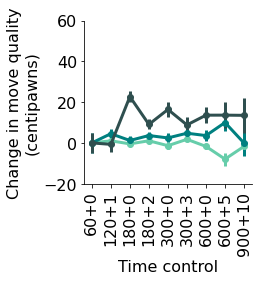

In [85]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.errorbar(xvals[0:9], np.asarray(avg_quality_rep3[0:9])-avg_quality_rep3[0], yerr = sem_quality_rep3[0:9], marker='o', color='mediumaquamarine', lw=3)
ax.errorbar(xvals[0:9], np.asarray(avg_quality_rep1[0:9])-avg_quality_rep1[0], yerr = sem_quality_rep1[0:9], marker='o', color='teal', lw=3)
ax.errorbar(xvals[0:9], np.asarray(avg_quality_rep2[0:9])-avg_quality_rep2[0], yerr = sem_quality_rep2[0:9], marker='o', color='darkslategray', lw=3)
ax.set_xlabel('Time control')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.set_ylim(-20,60)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# plt.savefig('rep_move_quality.png', format='png', dpi=1000,bbox_inches = 'tight')

## Move selection

In [11]:
# Get the move matching values for the time control setting (high voc)
target_moves = ['c8f5', 'h3f5']
high_time_controls_move = {move: [] for move in target_moves}
high_elos_move = {move: [] for move in target_moves}
high_move_match = {move: [] for move in target_moves}
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3', '600+0', '600+5', '900+10', '1800+0', '1800+20']
for ind in high_all.index:
    initial_clock = high_all['initial_clock'][ind]
    increment = high_all['clock_increment'][ind]
    if np.isnan(initial_clock) == False and np.isnan(increment) == False:
        time_control = str(int(initial_clock))+'+'+str(int(increment))
        if time_control in valid_controls:
            for move in target_moves:
                high_time_controls_move[move].append(time_control)
                high_elos_move[move].append(high_all['black_elo'][ind])
                high_move_match[move].append(1 if high_all['move_uci'][ind] == move else 0)

In [12]:
# Compute move match proportion as a function of time controls
avg_match_high = {move: [] for move in target_moves}
match_high = {move: np.asarray(high_move_match[move]) for move in target_moves}
for move in target_moves:
    for i in range(len(valid_controls)):
        idx = np.where(np.asarray(high_time_controls_move[move]) == valid_controls[i])
        p = np.nanmean(match_high[move][idx])
        avg_match_high[move].append(p.item())

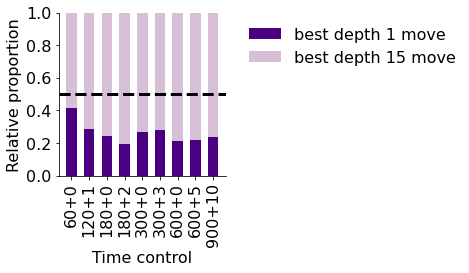

In [40]:
fig, ax = plt.subplots(figsize=(3, 3))

vals_c8f5 = np.array(avg_match_high['c8f5'][0:9])
vals_h3f5 = np.array(avg_match_high['h3f5'][0:9])
totals = vals_c8f5 + vals_h3f5

norm_c8f5 = vals_c8f5 / totals
norm_h3f5 = vals_h3f5 / totals

ax.bar(xvals[0:9], norm_c8f5, color='indigo', label='best depth 1 move', width=0.6)
ax.bar(xvals[0:9], norm_h3f5, bottom=norm_c8f5, color='thistle', label='best depth 15 move', width=0.6)

ax.set_xlabel('Time control')
ax.set_ylabel('Relative proportion')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.set_ylim(0, 1)
ax.axhline(0.5, color='black', linewidth=3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.show()
# plt.savefig('proportion_moves.png', format='png', dpi=1000,bbox_inches = 'tight')

In [22]:
# Get the move matching values for the time control setting (high voc)
target_moves = ['d2e4', 'e1f1']
rep2_time_controls_move = {move: [] for move in target_moves}
rep2_elos_move = {move: [] for move in target_moves}
rep2_move_match = {move: [] for move in target_moves}
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3', '600+0', '600+5', '900+10', '1800+0', '1800+20']
for ind in rep2_all.index:
    initial_clock = rep2_all['initial_clock'][ind]
    increment = rep2_all['clock_increment'][ind]
    if np.isnan(initial_clock) == False and np.isnan(increment) == False:
        time_control = str(int(initial_clock))+'+'+str(int(increment))
        if time_control in valid_controls:
            for move in target_moves:
                rep2_time_controls_move[move].append(time_control)
                rep2_elos_move[move].append(rep2_all['white_elo'][ind])
                rep2_move_match[move].append(1 if rep2_all['move_uci'][ind] == move else 0)

In [23]:
# Compute move match proportion as a function of time controls
avg_match_rep2 = {move: [] for move in target_moves}
match_rep2 = {move: np.asarray(rep2_move_match[move]) for move in target_moves}
for move in target_moves:
    for i in range(len(valid_controls)):
        idx = np.where(np.asarray(rep2_time_controls_move[move]) == valid_controls[i])
        p = np.nanmean(match_rep2[move][idx])
        avg_match_rep2[move].append(p.item())

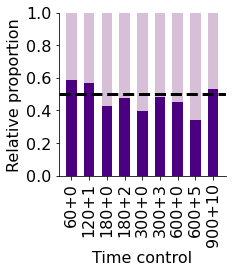

In [38]:
fig, ax = plt.subplots(figsize=(3, 3))

vals_d2e4 = np.array(avg_match_rep2['d2e4'][0:9])
vals_e1f1 = np.array(avg_match_rep2['e1f1'][0:9])
totals = vals_d2e4 + vals_e1f1

norm_d2e4 = vals_d2e4 / totals
norm_e1f1 = vals_e1f1 / totals

ax.bar(xvals[0:9], norm_d2e4, color='indigo', label='best depth 1 move', width=0.6)
ax.bar(xvals[0:9], norm_e1f1, bottom=norm_d2e4, color='thistle', label='best depth 15 move', width=0.6)

ax.set_xlabel('Time control')
ax.set_ylabel('Relative proportion')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(xvals[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.set_ylim(0, 1)
ax.axhline(0.5, color='black', linewidth=3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('rep_proportion_moves.png', format='png', dpi=1000,bbox_inches = 'tight')